# Task 3 — Step 5: Controlled Design Study — DAN-DG alignment strength

**Chosen study:** $\lambda_{\text{DG}}\in\{0.1,\,1,\,10\}$. Every other setting is identical to notebook 2 (Task 2 protocol, same MMD kernels, seed 6304, source-F1 selection). The main comparison keeps $\lambda_{\text{DG}}=1$ whatever happens here: Sketch results in this notebook are analysis only and cannot replace the main setting.

The grid is the manual's. It was not chosen from Task 2 Sketch results, which Task 3 settings may not depend on.

**Expectations, stated before any result.**
| | λ = 0.1 | λ = 1 | λ = 10 |
|---|---|---|---|
| Mean / worst source-val F1 | ≈ ERM | ≈ ERM or slightly lower | lower: the MMD term competes with CE |
| Pairwise source MMD² | slightly below ERM | lower | lowest |
| Source-domain separability (method-specific diagnostic) | slightly below ERM | lower | lowest; may approach chance |
| Sketch accuracy | ≈ ERM | uncertain | uncertain; stronger source invariance does not have to transfer to an unseen domain and may remove class-relevant cues |

Sections 1–2 use source data only. Sketch appears only in section 3.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

from shared.src.seed import set_seed, SEED
from shared.src.pacs_protocol import MAX_EPOCHS, PATIENCE
from shared.src.pacs_data import PACSDataset, PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.pacs_protocol import EVAL_TRANSFORM
from shared.src.plotting import use_style, SEQ_CMAP, PALETTE, DOMAIN_COLORS, NEUTRAL, INK_2, color_of, save_show
from sklearn.manifold import TSNE
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from task2_domain_adaptation.src.evaluate import collect_outputs
from task3_domain_generalization.src.train import get_source_loaders, train_dg
from task3_domain_generalization.src.evaluate import source_separability, fixed_sharpness_batch, sharpness_proxy, pairwise_mmd_matrix

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
CKPT = os.path.join(ROOT, 'task3_domain_generalization', 'checkpoints')
RES = os.path.join(ROOT, 'task3_domain_generalization', 'results')
T2_CKPT = os.path.join(ROOT, 'task2_domain_adaptation', 'checkpoints')
src_train, src_val = get_source_loaders(DATA, SPLIT)
LAMBDAS = [0.1, 1.0, 10.0]
LAM_COL = {0.1: PALETTE[3], 1.0: PALETTE[0], 10.0: PALETTE[6]}
def paths(lam):
    tag = 'dan_dg' if lam == 1.0 else f'dan_dg_lambda{lam:g}'
    return os.path.join(CKPT, f'{tag}.pth'), os.path.join(CKPT, f'{tag}_history.json')

## 1. Train the two additional settings (source data only)

[dan_dg] ep  1 | cls 0.486 | mmd 0.1070 | val F1 mean 0.8910 worst 0.8391 *
[dan_dg] ep  2 | cls 0.195 | mmd 0.0600 | val F1 mean 0.8810 worst 0.8483
[dan_dg] ep  3 | cls 0.139 | mmd 0.0514 | val F1 mean 0.9341 worst 0.8896 *
[dan_dg] ep  4 | cls 0.110 | mmd 0.0418 | val F1 mean 0.9227 worst 0.8932
[dan_dg] ep  5 | cls 0.071 | mmd 0.0281 | val F1 mean 0.9179 worst 0.8784
[dan_dg] ep  6 | cls 0.090 | mmd 0.0421 | val F1 mean 0.9496 worst 0.9259 *
[dan_dg] ep  7 | cls 0.069 | mmd 0.0295 | val F1 mean 0.9400 worst 0.9034
[dan_dg] ep  8 | cls 0.060 | mmd 0.0260 | val F1 mean 0.9358 worst 0.8927
[dan_dg] ep  9 | cls 0.058 | mmd 0.0358 | val F1 mean 0.9329 worst 0.9028
[dan_dg] ep 10 | cls 0.056 | mmd 0.0350 | val F1 mean 0.9199 worst 0.8644
[dan_dg] ep 11 | cls 0.046 | mmd 0.0161 | val F1 mean 0.9194 worst 0.8664
Early stopping at epoch 11; best epoch 6 (val F1 0.9496)
[dan_dg] ep  1 | cls 1.937 | mmd 0.0675 | val F1 mean 0.0507 worst 0.0421 *
[dan_dg] ep  2 | cls 1.949 | mmd 0.0445 | val F

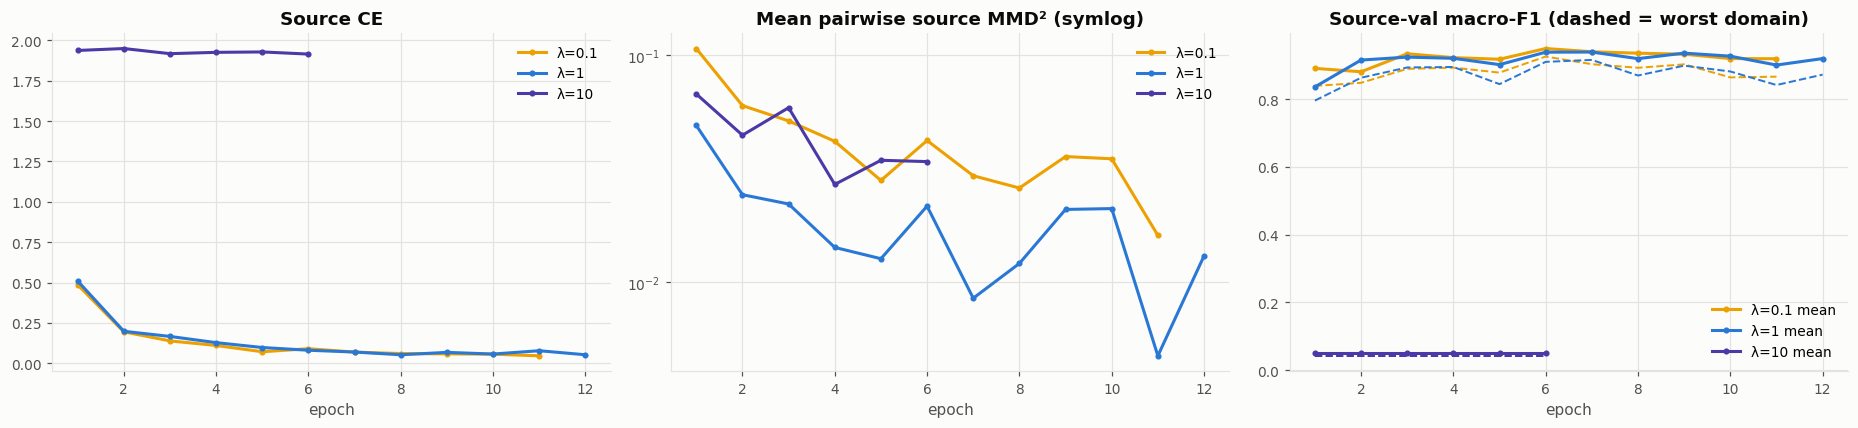

In [2]:
FORCE_TRAIN = True
for lam in LAMBDAS:
    ck, hp = paths(lam)
    if lam == 1.0:
        assert os.path.exists(ck), 'run notebook 2 first'; continue
    if FORCE_TRAIN or not os.path.exists(ck):
        set_seed(SEED)
        out = train_dg(ResNet18Backbone(num_classes=7), src_train, src_val, device, method='dan_dg', lambda_dg=lam,
                       max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=1e-4, wd=1e-4, save_path=ck)
        json.dump({'config': dict(method='dan_dg', lambda_dg=lam, lr=1e-4, wd=1e-4, max_epochs=MAX_EPOCHS, patience=PATIENCE, seed=SEED),
                   'history': out['history'], 'best_epoch': out['best_epoch'], 'best_f1': out['best_f1']}, open(hp, 'w'), indent=1)
hists = {lam: json.load(open(paths(lam)[1])) for lam in LAMBDAS}
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for lam in LAMBDAS:
    H = hists[lam]['history']; e = np.arange(1, len(H['cls_loss']) + 1)
    ax[0].plot(e, H['cls_loss'], 'o-', ms=3, color=LAM_COL[lam], label=f'λ={lam:g}')
    ax[1].plot(e, H['mmd_loss'], 'o-', ms=3, color=LAM_COL[lam], label=f'λ={lam:g}')
    ax[2].plot(e, H['val_mean_f1'], 'o-', ms=3, color=LAM_COL[lam], label=f'λ={lam:g} mean')
    ax[2].plot(e, H['val_worst_f1'], '--', lw=1.3, color=LAM_COL[lam])
ax[1].set_yscale('symlog', linthresh=1e-3)   # unbiased MMD² can dip slightly below 0
for a, t in zip(ax, ['Source CE', 'Mean pairwise source MMD² (symlog)', 'Source-val macro-F1 (dashed = worst domain)']):
    a.set_title(t); a.set_xlabel('epoch'); a.legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task3_controlled_training_curves.png'))

## 2. Source-side diagnostics (still no Sketch)

In [3]:
xb, yb = fixed_sharpness_batch(src_val, per_domain=32, seed=SEED); xb, yb = xb.to(device), yb.to(device)
nets, rows = {}, []
erm = ResNet18Backbone(num_classes=7).to(device); erm.load_state_dict(torch.load(os.path.join(T2_CKPT, 'source_only.pth'), map_location=device, weights_only=True))
for tag, net_path in [('ERM', None)] + [(f'λ={l:g}', paths(l)[0]) for l in LAMBDAS]:
    if net_path is None: net = erm
    else:
        net = ResNet18Backbone(num_classes=7).to(device); net.load_state_dict(torch.load(net_path, map_location=device, weights_only=True))
    nets[tag] = net
    o = {d: collect_outputs(net, src_val[d], device) for d in PACS_SOURCE_DOMAINS}
    f1s = [100 * f1_score(o[d][2], o[d][0].argmax(1), average='macro') for d in PACS_SOURCE_DOMAINS]
    rows.append({'setting': tag, **{f'{d} F1': v for d, v in zip(PACS_SOURCE_DOMAINS, f1s)}, 'mean src F1': np.mean(f1s), 'worst src F1': min(f1s),
                 'source separability': 100 * source_separability(net, src_val, device, seed=SEED)['source_separability'],
                 'Δ_sharp': sharpness_proxy(net, xb, yb, rho=0.05)['delta_sharp']})
study = pd.DataFrame(rows).set_index('setting')
study.round(3)

,photo F1,art_painting F1,cartoon F1,mean src F1,worst src F1,source separability,Δ_sharp
setting,,,,,,,
ERM,96.285,91.345,93.642,93.758,91.345,89.701,0.355
λ=0.1,96.991,92.586,95.291,94.956,92.586,84.053,0.285
λ=1,97.081,91.598,93.071,93.916,91.598,70.100,0.235
λ=10,5.850,5.143,4.208,5.067,4.208,67.110,0.036


### How much closer do the sources get as λ grows? (validation features only)
Top: pairwise source MMD² on 200 frozen validation features per domain (seed 6304), one matrix per setting on a shared colour scale. Bottom: one t-SNE per setting (seed 6304) coloured by domain.

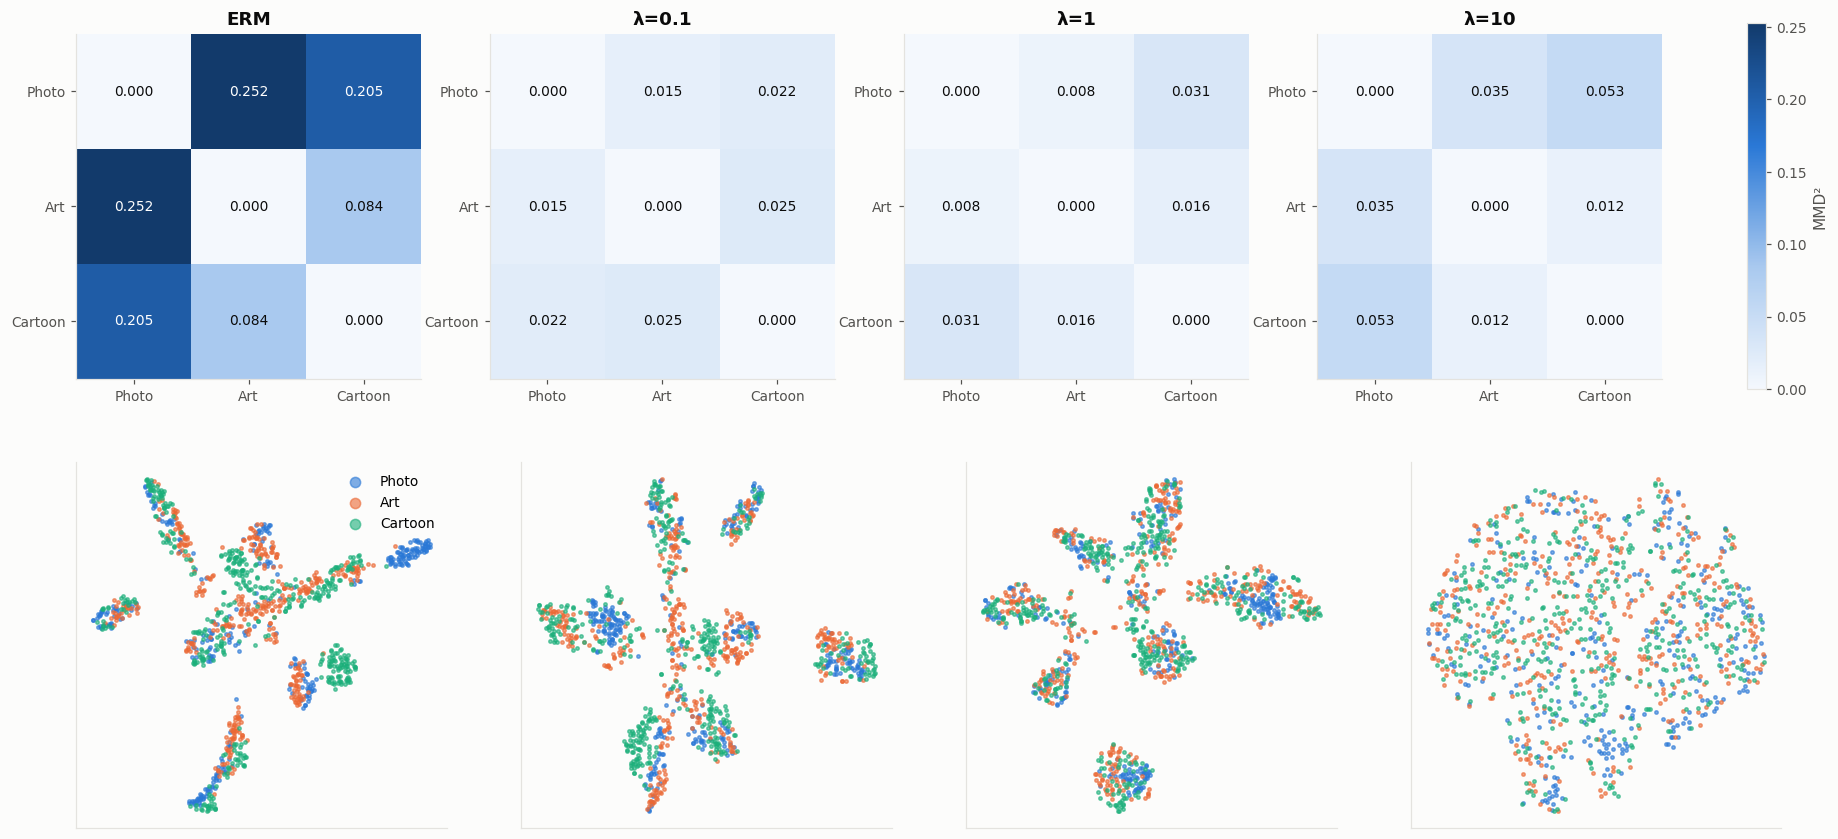

In [4]:
DOM_NAMES = {'photo': 'Photo', 'art_painting': 'Art', 'cartoon': 'Cartoon'}
vo = {tag: {d: collect_outputs(net, src_val[d], device) for d in PACS_SOURCE_DOMAINS} for tag, net in nets.items()}
mats = {tag: pairwise_mmd_matrix({d: o[d][1] for d in PACS_SOURCE_DOMAINS}, n=200, seed=SEED)[0] for tag, o in vo.items()}
vmax = max(M.max() for M in mats.values())
fig, axes = plt.subplots(2, len(nets), figsize=(5 * len(nets), 9.5))
for j, (tag, M) in enumerate(mats.items()):
    ax = axes[0, j]; im = ax.imshow(M, cmap=SEQ_CMAP, vmin=0, vmax=vmax)
    for a in range(3):
        for b in range(3): ax.text(b, a, f'{M[a, b]:.3f}', ha='center', va='center', fontsize=9, color='white' if M[a, b] > 0.6 * vmax else '#0b0b0b')
    ax.set_xticks(range(3)); ax.set_xticklabels(DOM_NAMES.values()); ax.set_yticks(range(3)); ax.set_yticklabels(DOM_NAMES.values()); ax.grid(False); ax.set_title(tag)
    Fv = np.concatenate([vo[tag][d][1] for d in PACS_SOURCE_DOMAINS]); Dv = np.concatenate([[d] * len(vo[tag][d][1]) for d in PACS_SOURCE_DOMAINS])
    E = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(Fv)
    for d in PACS_SOURCE_DOMAINS:
        axes[1, j].scatter(E[Dv == d, 0], E[Dv == d, 1], s=5, alpha=0.6, color=DOMAIN_COLORS[d], label=DOM_NAMES[d])
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
axes[1, 0].legend(markerscale=3); fig.colorbar(im, ax=axes[0, :], fraction=0.02, label='MMD²')
save_show(fig, os.path.join(RES, 'task3_controlled_mmd_tsne.png'))

## 3. Sketch (final analysis only)

In [5]:
sk = torch.utils.data.DataLoader(PACSDataset(DATA, 'sketch', EVAL_TRANSFORM), batch_size=64, shuffle=False)
per_class = {}
for tag, net in nets.items():
    lg, _, y = collect_outputs(net, sk, device)
    study.loc[tag, 'Sketch acc'] = 100 * (lg.argmax(1) == y).mean(); study.loc[tag, 'Sketch F1'] = 100 * f1_score(y, lg.argmax(1), average='macro')
    per_class[tag] = [100 * (lg.argmax(1)[y == c] == c).mean() for c in range(7)]
study['Δ Sketch acc vs ERM'] = study['Sketch acc'] - study.loc['ERM', 'Sketch acc']
study.to_csv(os.path.join(RES, 'task3_controlled_study.csv'))
study.round(3)

,photo F1,art_painting F1,cartoon F1,mean src F1,worst src F1,source separability,Δ_sharp,Sketch acc,Sketch F1,Δ Sketch acc vs ERM
setting,,,,,,,,,,
ERM,96.285,91.345,93.642,93.758,91.345,89.701,0.355,59.226,66.064,0.000
λ=0.1,96.991,92.586,95.291,94.956,92.586,84.053,0.285,65.742,67.989,6.516
λ=1,97.081,91.598,93.071,93.916,91.598,70.100,0.235,69.000,70.363,9.773
λ=10,5.850,5.143,4.208,5.067,4.208,67.110,0.036,4.072,1.118,-55.154


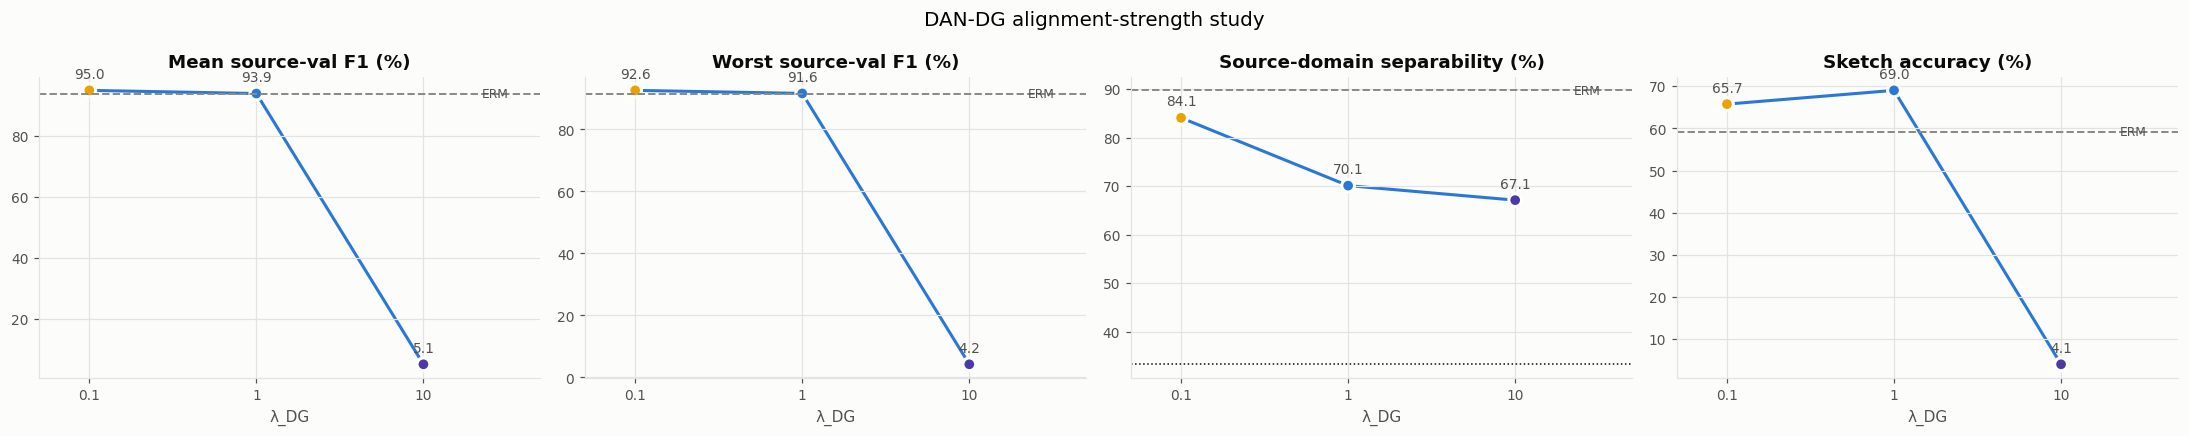

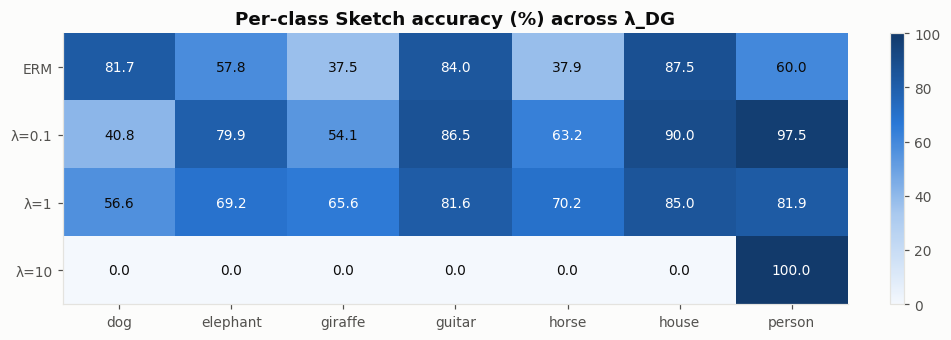

In [6]:
tags = [f'λ={l:g}' for l in LAMBDAS]; xs = np.arange(3)
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for a, (col, title) in zip(ax, [('mean src F1', 'Mean source-val F1 (%)'), ('worst src F1', 'Worst source-val F1 (%)'),
                                ('source separability', 'Source-domain separability (%)'), ('Sketch acc', 'Sketch accuracy (%)')]):
    v = study.loc[tags, col].values
    a.plot(xs, v, '-', color=color_of('DAN-DG'), zorder=1); a.scatter(xs, v, s=70, color=[LAM_COL[l] for l in LAMBDAS], edgecolor='white', linewidth=2, zorder=2)
    for x_, y_ in zip(xs, v): a.annotate(f'{y_:.1f}', (x_, y_), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9, color=INK_2)
    a.axhline(study.loc['ERM', col], color=NEUTRAL, ls='--', lw=1.3); a.text(2.35, study.loc['ERM', col], 'ERM', fontsize=8, color=INK_2, va='center')
    a.set_xticks(xs); a.set_xticklabels([f'{l:g}' for l in LAMBDAS]); a.set_xlabel('λ_DG'); a.set_title(title); a.set_xlim(-0.3, 2.7)
ax[2].axhline(100 / 3, color='#0b0b0b', ls=':', lw=1)
fig.suptitle('DAN-DG alignment-strength study', fontsize=13); fig.tight_layout()
save_show(fig, os.path.join(RES, 'task3_controlled_tradeoff.png'))
pcd = pd.DataFrame(per_class, index=PACS_CLASSES)
fig, a = plt.subplots(figsize=(10, 3.2))
im = a.imshow(pcd.T.values, cmap=SEQ_CMAP, vmin=0, vmax=100, aspect='auto')
for i in range(pcd.shape[1]):
    for j in range(7): v = pcd.T.values[i, j]; a.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=9, color='white' if v > 60 else '#0b0b0b')
a.set_xticks(range(7)); a.set_xticklabels(PACS_CLASSES); a.set_yticks(range(pcd.shape[1])); a.set_yticklabels(pcd.columns); a.grid(False)
a.set_title('Per-class Sketch accuracy (%) across λ_DG'); fig.colorbar(im, ax=a, fraction=0.03)
save_show(fig, os.path.join(RES, 'task3_controlled_per_class.png'))